
# Regresión Lineal Simple

## Fundamentos

La regresión lineal simple es una técnica estadística utilizada para modelar la relación entre dos variables cuantitativas: una independiente (X) y una dependiente (y).
El objetivo es encontrar una línea recta que mejor describa cómo cambia y al variar X.

## Modelo Matemático

$$
\hat y = \beta_0 + \beta_1 x + \epsilon
$$

- β₀: intersección o término independiente.
- β1: pendiente, que representa cuánto cambia y cuando x aumenta en una unidad.

- ε es el término de error.

## Descripción de librerías, clases, funciones y parámetros
- pandas (pd): carga y manipulación del dataset (read_csv, DataFrame).
- numpy (np): operaciones numéricas.
- matplotlib.pyplot (plt) y seaborn (sns): visualización (histogramas, dispersión, curvas).

- sklearn.model_selection.train_test_split: separar datos de entrenamiento y prueba.

- sklearn.linear_model.LinearRegression: ajusta los coeficientes mediante mínimos cuadrados.



### Importar librerías y carga del dataset

# **Pipeline**

## **+ Preprocesamiento**
En esta etapa se realiza un análisis exploratorio del dataset para comprender su estructura, distribución y comportamiento general.

Se muestran estadísticas básicas y gráficas que permiten detectar relaciones entre las variables.

- Se aplican comandos como df.describe() para obtener estadísticas básicas
(media, desviación estándar, valores mínimos y máximos)
- Se visualiza la distribución de salarios con seaborn.histplot.

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Cargar dataset
df_sal = pd.read_csv('Salary_Data.csv')
df_sal.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [18]:
# Estadísticas descriptivas
df_sal.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


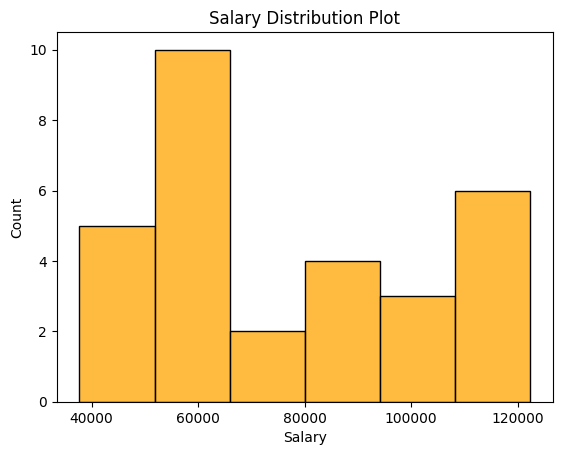

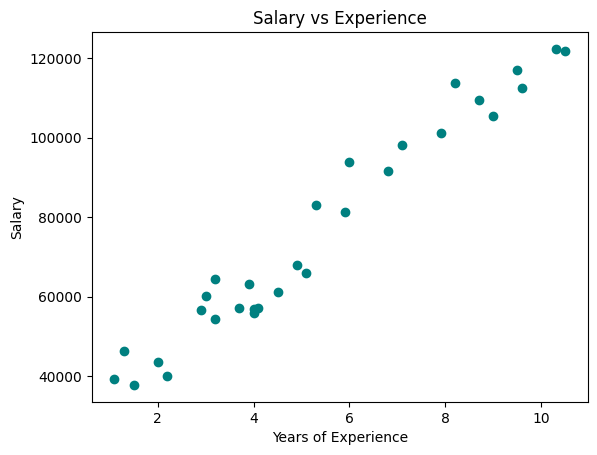

In [19]:
# Distribución de salarios
plt.title('Salary Distribution Plot')
sns.histplot(df_sal['Salary'], color='orange')
plt.show()

# Gráfico de dispersión (relación entre experiencia y salario)
plt.scatter(df_sal['YearsExperience'], df_sal['Salary'], color='teal')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## **+ Feature Engineering**

En esta etapa se identifican las variables independientes y dependientes:
##### Variable independiente (X):
- YearsExperience : representa los años de experiencia del empleado.
Es una variable numérica continua.

##### Variable dependiente (y):
- Salary : representa el salario correspondiente a la experiencia.
Es también una variable numérica continua.

In [20]:

## Splitting variables
X = df_sal.iloc[:, :1]  # independent
y = df_sal.iloc[:, 1:]  # dependent

## **+ Model Selection**

Se utiliza un modelo lineal simple porque los datos muestran una relación aproximadamente proporcional entre los años de experiencia y el salario.
La dispersión es creciente pero sigue una tendencia recta, por lo que no es necesario un modelo polinomial si no lineal.


## **+ Model Training**

#### En esta parte se entrena el modelo para que aprenda la relación entre experiencia y salario.
##### Se dividen los datos en dos partes:

- Entrenamiento (80%): el modelo aprende con estos datos.

- Prueba (20%): se usan para comprobar si el modelo generaliza bien.

##### Se crea el modelo con LinearRegression() y se entrena con fit().

##### Finalmente, se muestran los valores que el modelo aprendió:

- Beta_0 (intercepto): el salario base (cuando la experiencia es 0).

- Beta_1 (pendiente): cuánto aumenta el salario por cada año adicional de experiencia.


In [21]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


In [22]:

## Regressor model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## **+ Prediction**

#### Aqui usamos el modelo entrenado para:
- Obtener predicciones en train (para ver ajuste) y en test (para ver generalización).

- Hacer predicciones puntuales (p. ej. salario esperado con 5.5 años).

#### visualización:
- En train: scatter de X_train vs y_train + recta y_pred_train.

- En test: scatter de X_test vs y_test; la recta puede ser la ajustada con X_train para mostrar consistencia.



In [23]:
# Predicciones
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

### Visualización de predicciones

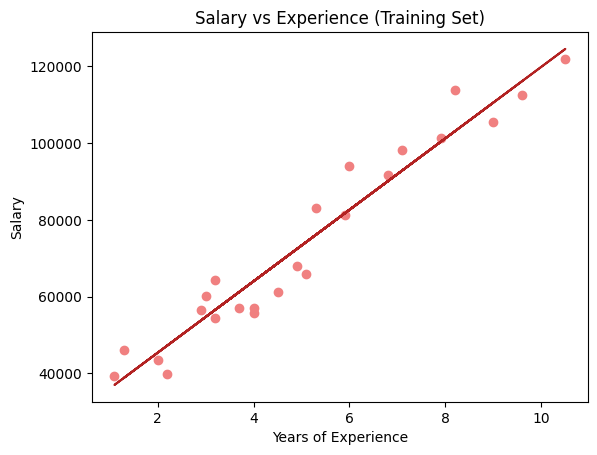

In [24]:
# Entrenamiento
plt.scatter(X_train, y_train, color='lightcoral')
plt.plot(X_train, y_pred_train, color='firebrick')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()



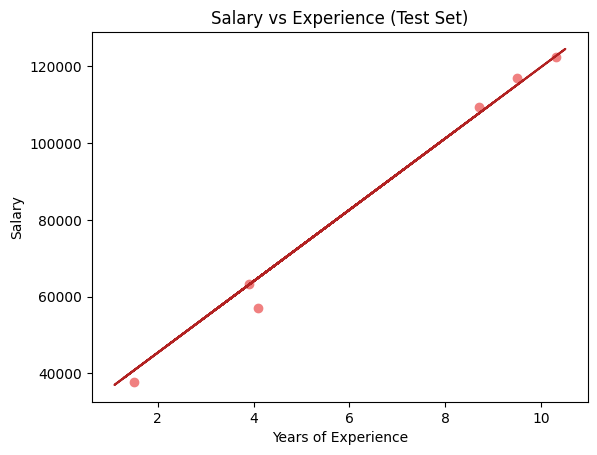

In [25]:
# Prueba
plt.scatter(X_test, y_test, color='lightcoral')
plt.plot(X_train, y_pred_train, color='firebrick')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

$\beta0 \ and \ \beta1$

In [26]:
## Parameters optimum calues
print(f'Beta_0: {regressor.intercept_}')
print(f'Beta_1: {regressor.coef_}')

Beta_0: [26780.09915063]
Beta_1: [[9312.57512673]]


## **+ Model Evaluation**

Se calculan métricas como el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R²)
para comparar el desempeño entre los modelos lineal y polinomial.

- Cuanto menor sea el MSE, mejor es el ajuste del modelo  
- R^2 cuanto más cercano a 1, mejor explica el modelo los datos.

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

# Métricas de evaluación
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f'Training set -> MSE: {mse_train}, R²: {r2_train:}')
print(f'Test set -> MSE: {mse_test:}, R²: {r2_test}')

Training set -> MSE: 36149670.11816131, R²: 0.9411949620562126
Test set -> MSE: 12823412.298126549, R²: 0.988169515729126


## **Referencias**

- Donnelly, H. (2021, 22 May). Introduction to Machine Learning: Regression.Medium

- scikit-learn developers. (s.f.). r2_score. Scikit-learn.

- scikit-learn developers. (s.f.). mean_squared_error. Scikit-learn.